## Get and Format Data
### Only do this once (until someone changes the code)
1. Run all blocks in notebooks/bipartite_graph.ipynb
2. cd into notebooks
2. Run process_graphs.py
3. Run run_simulations.py (there are hyperparameters on the number of trajectories to simulate and expansion types)
4. Run this notebook

In [1]:
# General imports
import sys
import os
import numpy as np

# PyTorch 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv 
from torch_geometric.nn import GATv2Conv


# ----File Stitching----
# If in models folder, cd back to notebooks folder
if os.path.basename(os.getcwd()) == "models":
    os.chdir('..')
# If a file is in /src/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

# Import from .py files 
from training import load_and_prepare_training_data, ImitationTrainer # Training script handles dataloaders 
train_dataloader, val_dataloader, static_graph = load_and_prepare_training_data()
node_dim = static_graph['x_static'].shape[1] + 1 
_, _, _, sample_event_feat = next(iter(train_dataloader))
event_dim = sample_event_feat.shape[1]

Loading imitation data...
Splitting data with 20.0% validation ratio...
Building PyTorch Train DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...
Building PyTorch Validation DataLoader...
Loading static graph topology...
Aligning static user features...
Aligning event features...


### Setting to GPU

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Define Model

### Input: Hyper Graphs Only

In [3]:
# Adapted code from 
    # https://towardsdatascience.com/graph-attention-networks-in-python-975736ac5c0c/
    # https://www.github.com/diegoantognini/pyGAT/blob/master/

# Define a Graph Attention Model class
class GAT_hyper(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, heads=1, edge_dim=1): # Maybe increase num heads later?
        super().__init__()
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, edge_dim=edge_dim)
        self.gat2 = GATv2Conv(hidden_dim * heads, out_dim, heads=1, edge_dim=edge_dim)

    def forward(self,x_batch, static_graph, event_feat_batch): 
        # Obtain x_batch dimensions
        B, N, _ = x_batch.shape
        x_nodes_list =[]
        # For each node in x_batch, run it through a Gatv2Conv layer
        for b in range(B):
            x_b = x_batch[b]
            # Implement dropout to limit overfitting
            h = F.dropout(x_b, p=0.2, training=self.training)
            h = self.gat1(x_b, static_graph['edge_index_2'],static_graph['edge_attr_2'])
            h = F.elu(h)
            # h = F.dropout(h, p=0.2, training=self.training)
            h = self.gat2(h,static_graph['edge_index_2'],static_graph['edge_attr_2'])
            x_nodes_list.append(h)
        # Combine all the nodes into a single tensor
        batch_x_nodes = torch.stack(x_nodes_list)
        batch_x_nodes = batch_x_nodes.squeeze(2)
        return batch_x_nodes

## Run Training Script

#### Input: Hyper Graphs Only


Initializing model with Node Dim: 9, Event Dim: 64

--------TESTING LEARNING RATE 1e-05 AND WEIGHT DECAY 1e-05--------


Starting Training...
Starting training on cpu...


New best model saved at epoch 1 (Val BCE: 1203.9883)
Epoch 1/4 | Train BCE: 1223.4106 | Val BCE: 1203.9883


New best model saved at epoch 2 (Val BCE: 1164.7952)
Epoch 2/4 | Train BCE: 1184.1079 | Val BCE: 1164.7952


New best model saved at epoch 3 (Val BCE: 1125.7285)
Epoch 3/4 | Train BCE: 1145.0000 | Val BCE: 1125.7285


New best model saved at epoch 4 (Val BCE: 1087.0433)
Epoch 4/4 | Train BCE: 1106.2782 | Val BCE: 1087.0433
Training complete.
Loss curve saved to loss_curve.png
Loss curve saved to loss_curve.png


ValueError: zero-size array to reduction operation minimum which has no identity

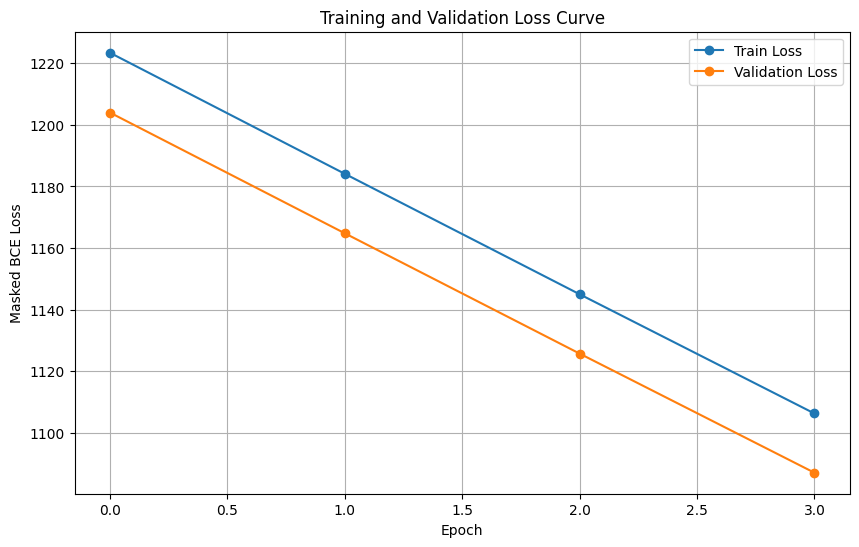

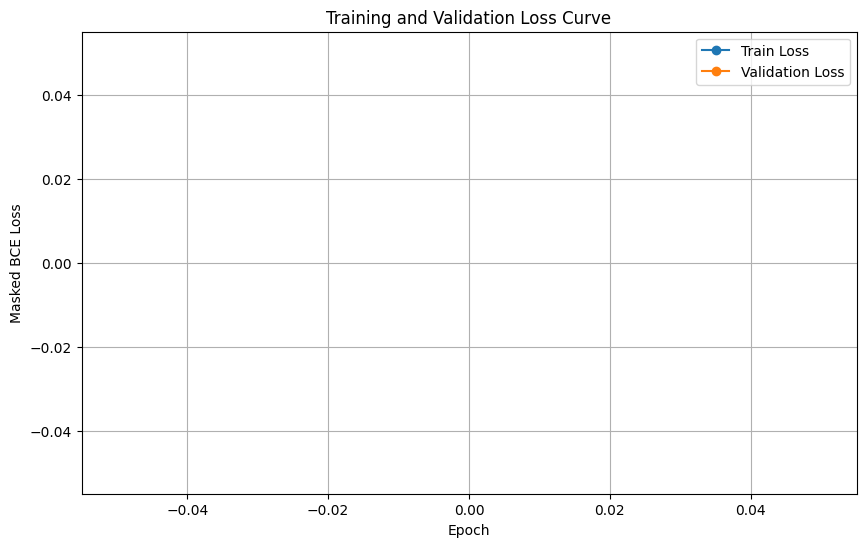

In [ ]:
print(f"\nInitializing model with Node Dim: {node_dim}, Event Dim: {event_dim}")

model_hyper = GAT_hyper(
    in_dim = -1,
    hidden_dim = 8,
    out_dim = 1
)


learning_rates = [1e-5, 1e-3, 1e-1]
weight_decays = [1e-5, 1e-3, 1e-1]
all_train_losses = []; all_val_losses = []
best_model = None
best_trainer = None
best_loss = np.inf

for i in range(len(learning_rates)):

    for j in range(len(weight_decays)):
        
        config = {
                    'lr': learning_rates[i],
                    'weight_decay': weight_decays[j],
                    'epochs': 4, # 4 epochs sufficient for hyperparameter tuning
                    'project_name': 'meetup-contagion-seeding',
                    'run_name': 'GAT_hyper_run'
                }
        
        print(f"\n--------TESTING LEARNING RATE {learning_rates[i]} AND WEIGHT DECAY {weight_decays[i]}--------\n")

        trainer_hyper = ImitationTrainer(
            model=model_hyper,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            static_graph=static_graph,
            config=config,
            use_wandb=False # Switch to False if wandb is not set up
        )

        print("\nStarting Training...")
        trainer_hyper.train()
        trainer_hyper.plot_losses()
        all_train_losses.append(trainer_hyper.history['train_loss'])
        all_val_losses.append(trainer_hyper.history['val_loss'])

        if np.min(trainer_hyper.history['val_loss']) < best_loss:
            best_loss = np.min(trainer_hyper.history['val_loss'])
            best_lr = learning_rates[i]
            best_weight_decay = weight_decays[j]
            best_trainer = trainer_hyper
            best_model = model_hyper

print(f"\n--------BEST LEARNING RATE: {best_lr}\nBEST WEIGHT DECAY: {best_weight_decay}--------")
best_trainer.plot_losses()

In [9]:
print(trainer_hyper.history)

{'train_loss': [], 'val_loss': []}


In [11]:
print(all_train_losses)
print(all_val_losses)

[[]]
[[]]
